# 1- Data Preprocessing

### 1.1 Loading data 

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/Users/Safa/code/Reenad-Alzahrani/Medical_Insurance_Cost_Prediction/raw_data/medical_insurance.csv')
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


### 1.2 Inspect the Schema and Get Descriptive Statistics

**Overview:**
- The dataset contains **100,000 rows** and **54 columns**, with a mix of **numeric** and **categorical** features.

**Numeric Columns:**
- Columns like `age`, `income`, `bmi`, and medical procedure counts (`proc_*`) provide meaningful statistics:
  - Mean, standard deviation, min/max values
  - Percentiles (25%, 50%, 75%) for distribution insights
- Example: `income` ranges from **1,100** to **1,061,800**, with a mean of **49,874**.

**Categorical Columns:**
- Columns such as `sex`, `region`, `education`, and `employment_status` show:
  - Number of unique categories
  - Most frequent category (`top`) and its count (`freq`)
- Example: `sex` has 3 categories, with **Female** being the most common (49,193 entries).

In [3]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (100000, 54)


In [4]:
print("Column names:", df.columns.tolist())

Column names: ['person_id', 'age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']


##### Inspect data types

In [5]:
print(df.dtypes)

person_id                        int64
age                              int64
sex                             object
region                          object
urban_rural                     object
income                         float64
education                       object
marital_status                  object
employment_status               object
household_size                   int64
dependents                       int64
bmi                            float64
smoker                          object
alcohol_freq                    object
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                    float64
diastolic_bp                   float64
ldl                            float64
hba1c                          float64
plan_type                       object
network_tier                    object
deductible                       int64
copay                    

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

#### Get descriptive statistics

In [7]:
df.describe(include='all')

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,100000,100000,100000,1.000000e+05,100000,100000,100000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
unique,NaN,NaN,3,5,3,NaN,6,4,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Female,South,Urban,NaN,Bachelors,Married,Employed,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,49193,28029,60019,NaN,27996,53252,55269,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,50000.500000,47.521500,NaN,NaN,NaN,4.987390e+04,NaN,NaN,NaN,2.430900,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,NaN,NaN,NaN,4.680021e+04,NaN,NaN,NaN,1.075126,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,NaN,NaN,NaN,1.100000e+03,NaN,NaN,NaN,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,NaN,NaN,NaN,2.110000e+04,NaN,NaN,NaN,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,NaN,NaN,NaN,3.620000e+04,NaN,NaN,NaN,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,NaN,NaN,NaN,6.220000e+04,NaN,NaN,NaN,3.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000


**This summary provides a quick snapshot of data distributions, common values, and potential anomalies. It helps guide preprocessing decisions such as encoding, scaling, and outlier handling.**

### 1.3 Handle Missing Data

We checked for missing values across all columns and found that `alcohol_freq` had approximately 30% missing entries. This column is categorical with three levels: `Occasional`, `Weekly`, and `Daily`.

**Imputation Strategy:**  
Since `alcohol_freq` is non-numeric and unordered, we imputed missing values using the **most frequent category**, which was `Occasional`.


In [8]:
#counting the percentage of NaN for each coulmn
df.isnull().sum().sort_values(ascending=False) / len(df)

alcohol_freq                   0.30083
person_id                      0.00000
sex                            0.00000
region                         0.00000
urban_rural                    0.00000
age                            0.00000
income                         0.00000
education                      0.00000
employment_status              0.00000
marital_status                 0.00000
household_size                 0.00000
dependents                     0.00000
bmi                            0.00000
smoker                         0.00000
visits_last_year               0.00000
hospitalizations_last_3yrs     0.00000
days_hospitalized_last_3yrs    0.00000
medication_count               0.00000
systolic_bp                    0.00000
diastolic_bp                   0.00000
ldl                            0.00000
hba1c                          0.00000
plan_type                      0.00000
network_tier                   0.00000
deductible                     0.00000
copay                    

In [9]:
# Count the number of missing values in the 'alcohol_freq' column
missing_rows = df['alcohol_freq'].isnull().sum()
print("missing values:", missing_rows)

missing values: 30083


In [10]:
#percentage of missing values in alcohol_freq
(df.alcohol_freq.isnull().sum() / len(df))

np.float64(0.30083)

In [11]:
# Display the frequency of each category in the 'alcohol_freq' column
df['alcohol_freq'].value_counts()

alcohol_freq
Occasional    45078
Weekly        19833
Daily          5006
Name: count, dtype: int64

In [12]:
# Impute missing values in the 'alcohol_freq' column with the most frequent value (mode)
df['alcohol_freq'].fillna(df['alcohol_freq'].mode()[0], inplace=True)

/var/folders/5y/6939r6q57sx9738c92nhs3d80000gn/T/ipykernel_50748/3212561218.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['alcohol_freq'].fillna(df['alcohol_freq'].mode()[0], inplace=True)


In [13]:
df['alcohol_freq'].isnull().sum()

np.int64(0)

**Result:**  
All missing values in `alcohol_freq` have been filled, and the column is now complete with no null entries.

### 1.4 Normalize Column Names and Formats

To ensure consistency and avoid issues during preprocessing and modeling, we standardized all column names using a normalization function.

**Steps:**  
- Removes leading/trailing spaces  
- Converts all names to lowercase  
- Replaces spaces with underscores  
- Ensures compatibility with code, especially when referencing columns programmatically



In [14]:
df.columns

Index(['person_id', 'age', 'sex', 'region', 'urban_rural', 'income',
       'education', 'marital_status', 'employment_status', 'household_size',
       'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year',
       'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs',
       'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c',
       'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years',
       'policy_changes_last_2yrs', 'provider_quality', 'risk_score',
       'annual_medical_cost', 'annual_premium', 'monthly_premium',
       'claims_count', 'avg_claim_amount', 'total_claims_paid',
       'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd',
       'cardiovascular_disease', 'cancer_history', 'kidney_disease',
       'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count',
       'proc_surgery_count', 'proc_physio_count', 'proc_consult_count',
       'proc_lab_count', 'is_high_risk', 'had_major_procedure'],
      

In [15]:
def normalize_column_names(data):
    return data.columns.str.strip().str.lower().str.replace(' ', '_')

In [16]:
df.columns = normalize_column_names(df)

### 1.5 Clean data

#### cheak for duplication

In [17]:
df.duplicated().sum()

np.int64(0)

**The data is clean and not duplicated**

#### Cheak columns with unreasonable or incorrect values

**We performed a thorough inspection of both numeric and categorical columns to ensure data integrity before modeling.**

**Numeric Columns (`df.describe()`):**  
- All 44 numeric features have valid ranges and no missing values.  
- No negative values in columns where they would be illogical (e.g., `age`, `income`, `bmi`, `hospitalizations`).  
- Maximum values are high but plausible given the dataset size (e.g., `income` up to 1,061,800 and `age` up to 100).  
- No obvious data entry errors (e.g., zero age with high income, or extreme BMI values below 12 or above 50.4).

**Categorical Columns (`df.select_dtypes(include='object')`):**  
- All categories are well-defined and consistent.  
- No typos, nulls, or unexpected values in columns like `sex`, `region`, `education`, `employment_status`, etc.  
- Each column contains a reasonable set of unique values:
  - `sex`: Female, Male, Other  
  - `region`: North, Central, West, South, East  
  - `education`: No HS, HS, Some College, Bachelors, Masters, Doctorate  
  - `employment_status`: Employed, Unemployed, Retired, Self-employed  
  - `network_tier`: Bronze, Silver, Gold, Platinum

✅ The dataset is clean and ready for preprocessing. No unreasonable or incorrect values were detected.

In [18]:
df.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


In [19]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

sex: ['Female' 'Male' 'Other']
region: ['North' 'Central' 'West' 'South' 'East']
urban_rural: ['Suburban' 'Urban' 'Rural']
education: ['Doctorate' 'No HS' 'HS' 'Some College' 'Masters' 'Bachelors']
marital_status: ['Married' 'Single' 'Divorced' 'Widowed']
employment_status: ['Retired' 'Employed' 'Self-employed' 'Unemployed']
smoker: ['Never' 'Current' 'Former']
alcohol_freq: ['Occasional' 'Weekly' 'Daily']
plan_type: ['PPO' 'POS' 'HMO' 'EPO']
network_tier: ['Bronze' 'Gold' 'Platinum' 'Silver']


#### Detect Outliers Across All Numeric Features

To ensure data quality and model robustness, we performed a comprehensive outlier analysis across all numeric columns.

**Step 1: Visual Inspection**  
We generated boxplots for each numeric feature to visually assess the presence of extreme values and distribution skewness.

**Step 2: Statistical Detection (IQR Method)**  
Using the interquartile range (IQR), we calculated outlier thresholds for each column:
- `Lower bound = Q1 - 1.5 × IQR`
- `Upper bound = Q3 + 1.5 × IQR`  
Values outside this range were flagged as outliers.


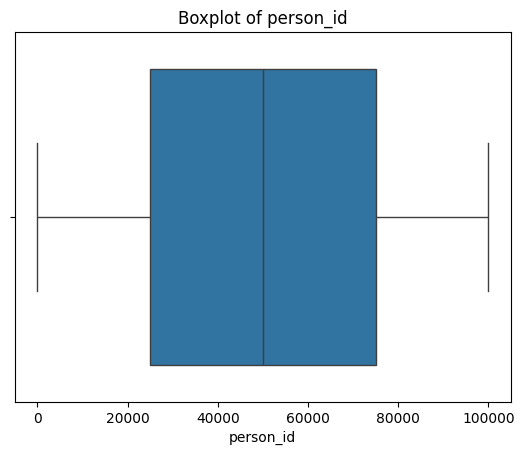

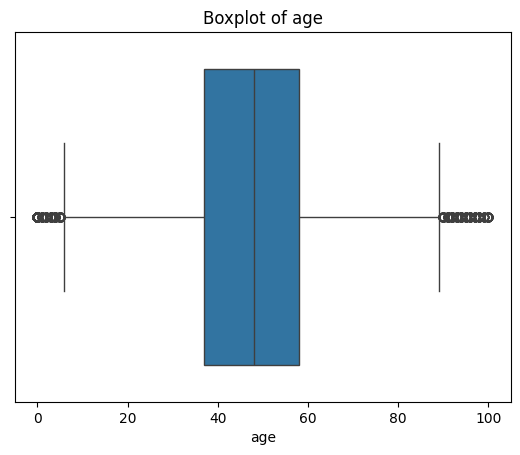

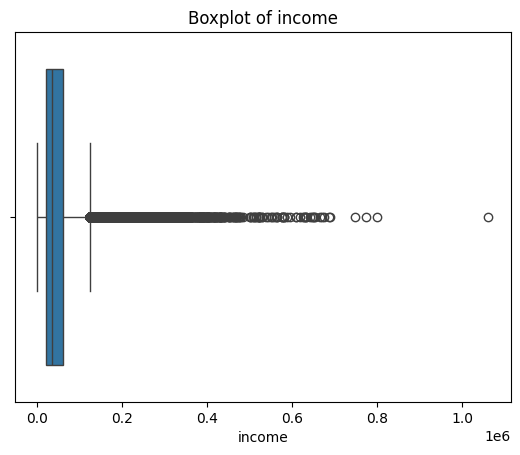

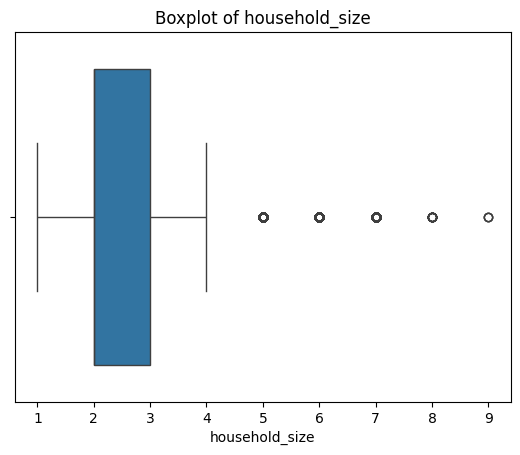

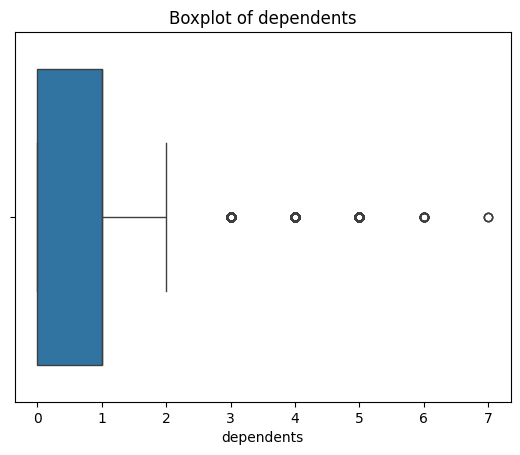

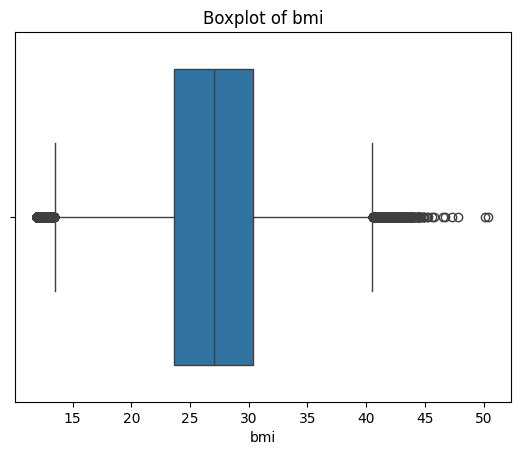

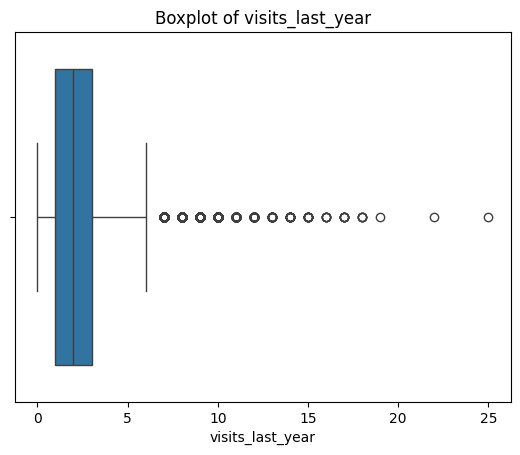

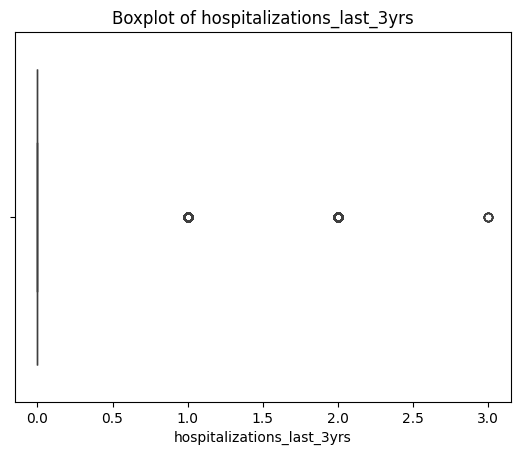

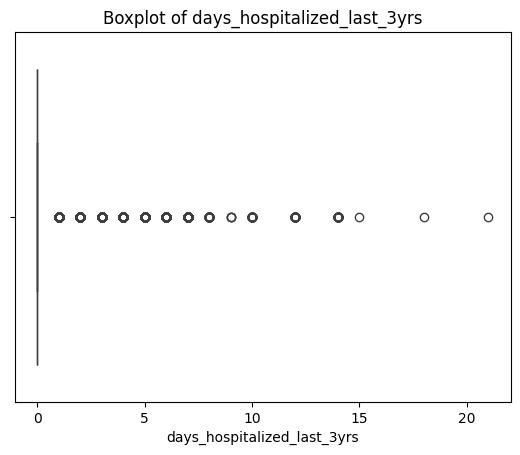

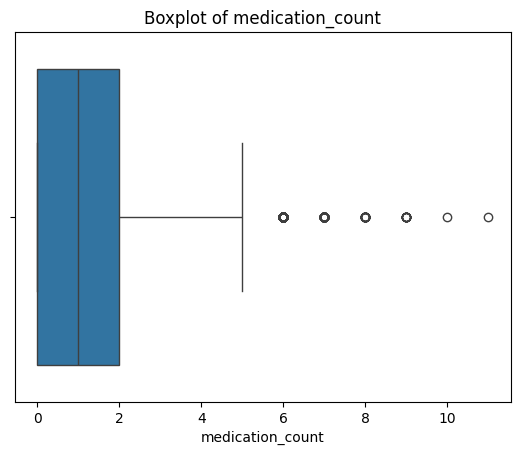

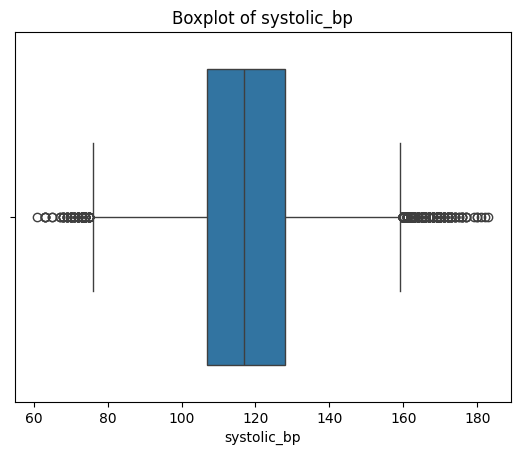

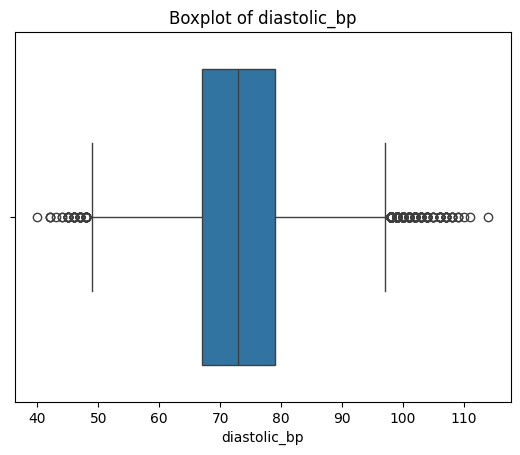

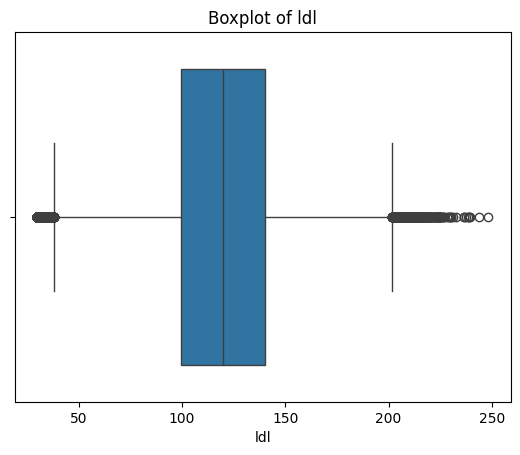

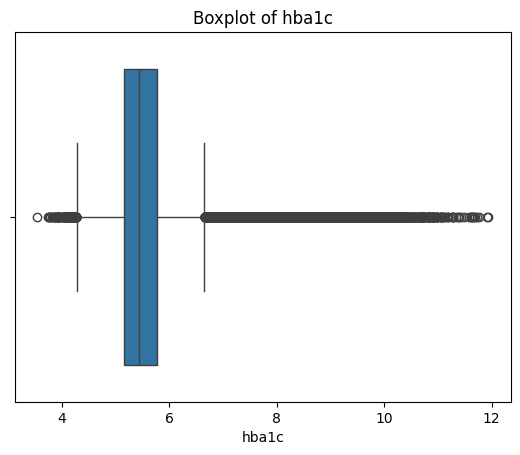

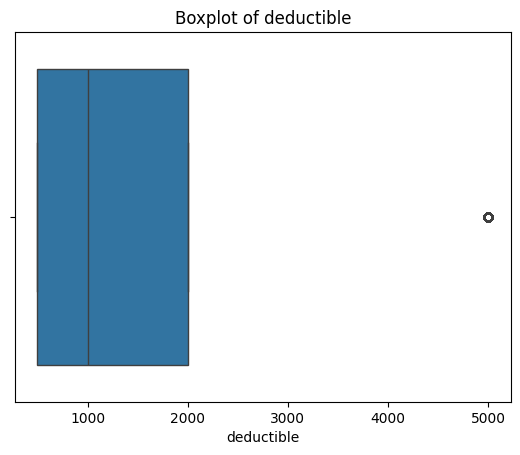

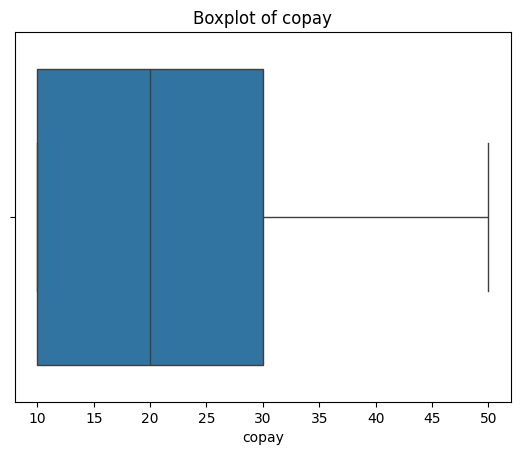

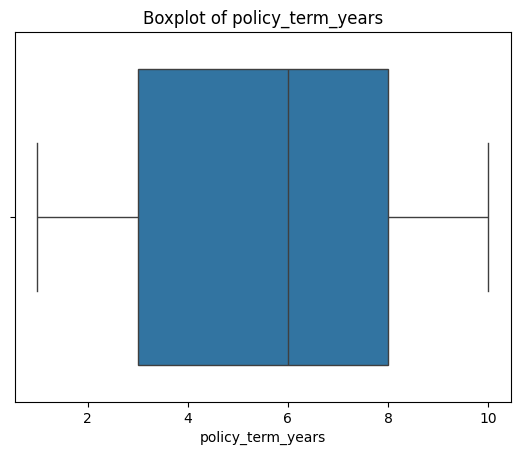

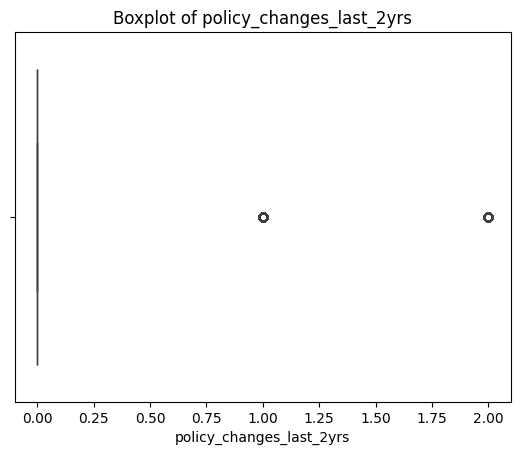

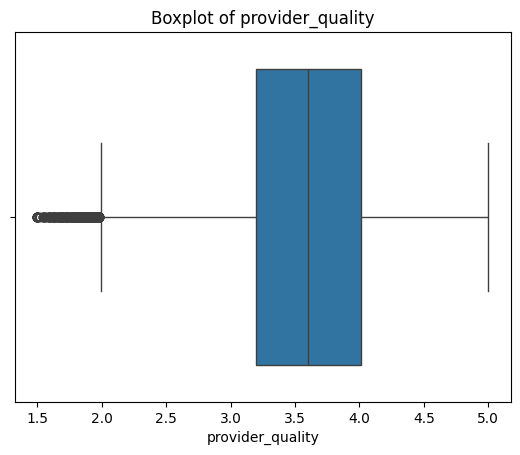

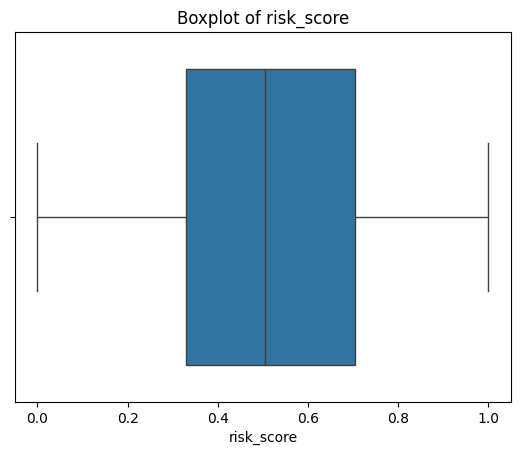

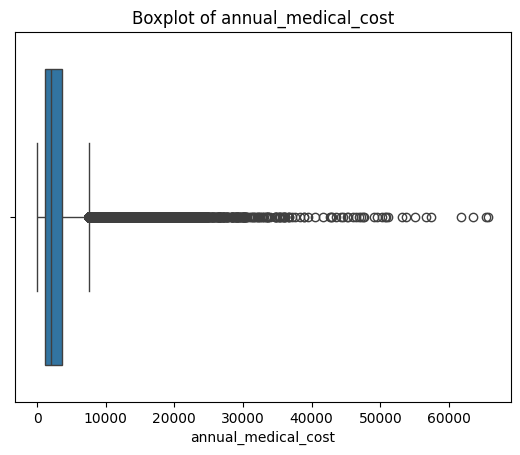

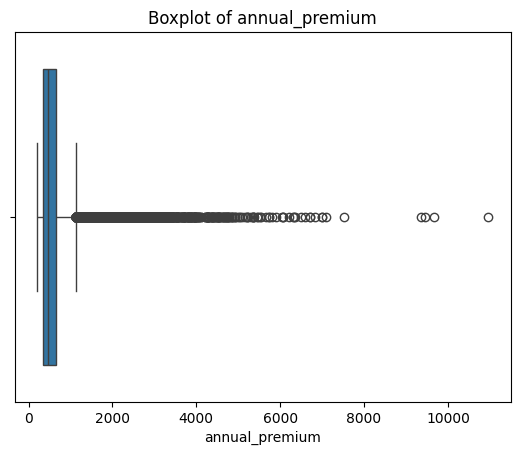

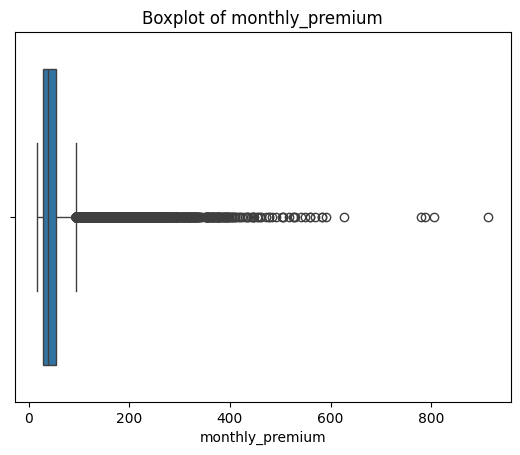

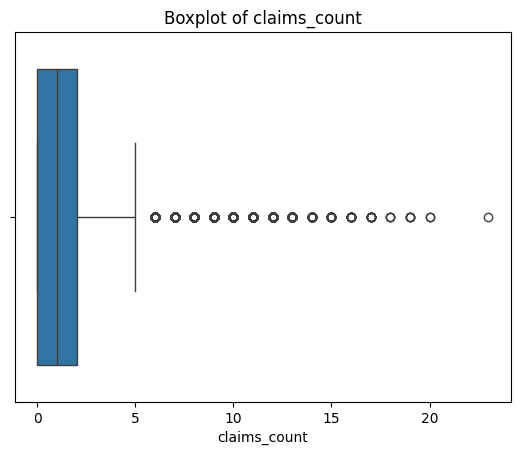

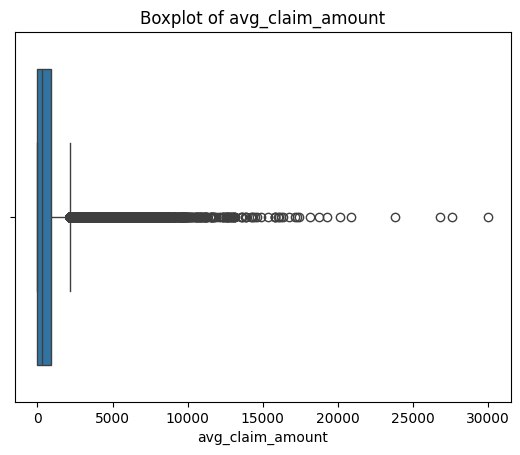

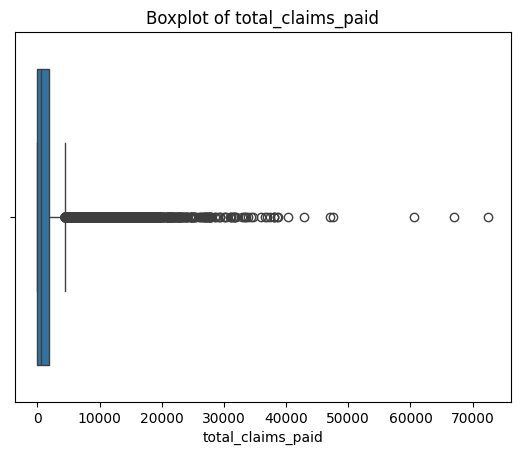

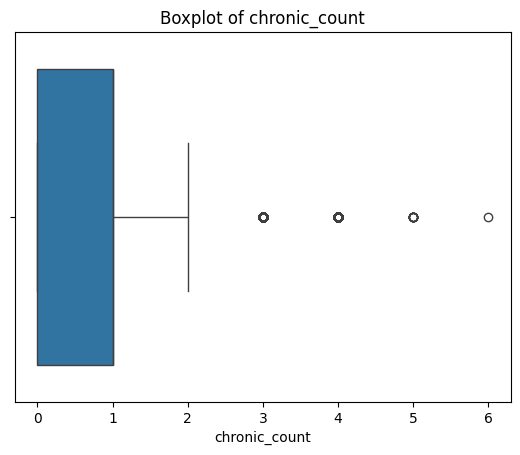

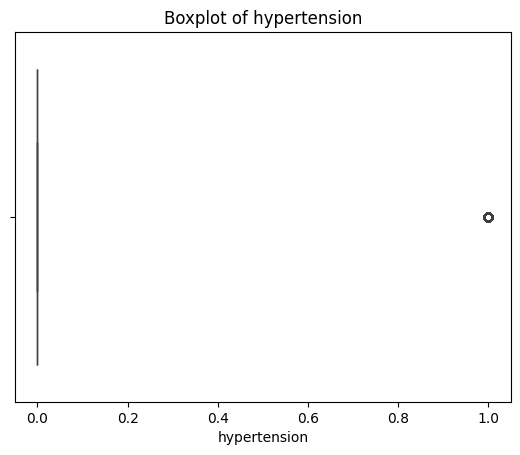

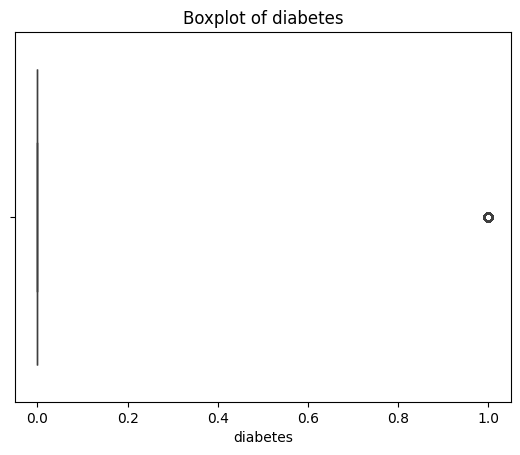

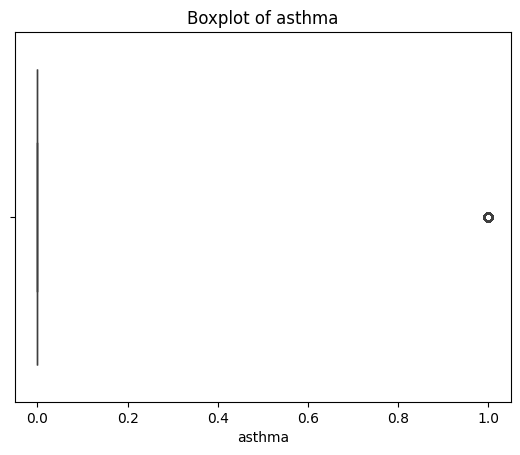

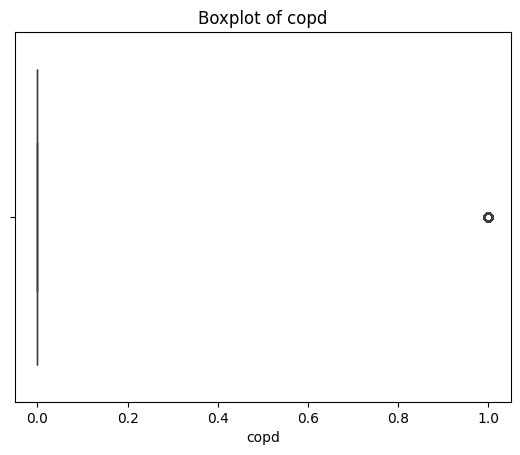

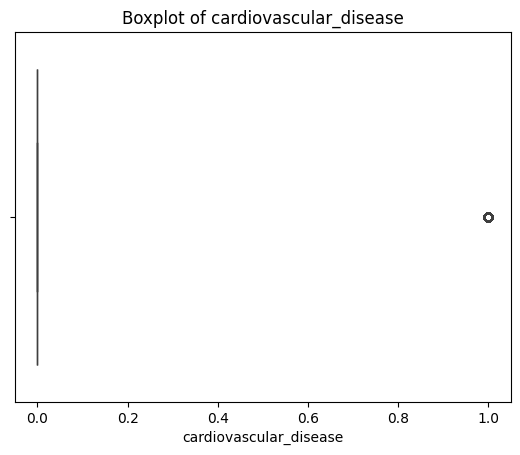

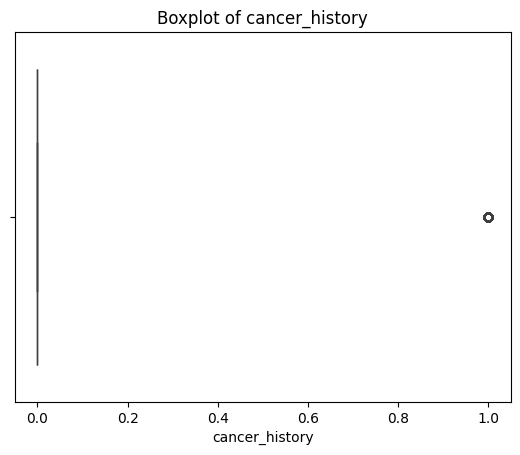

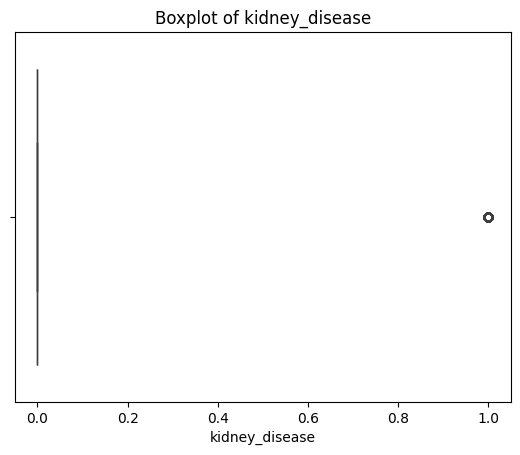

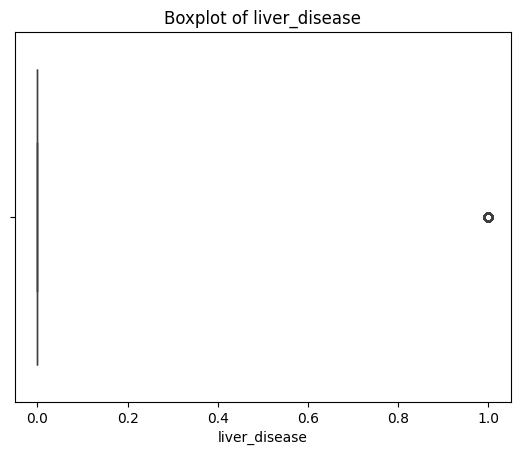

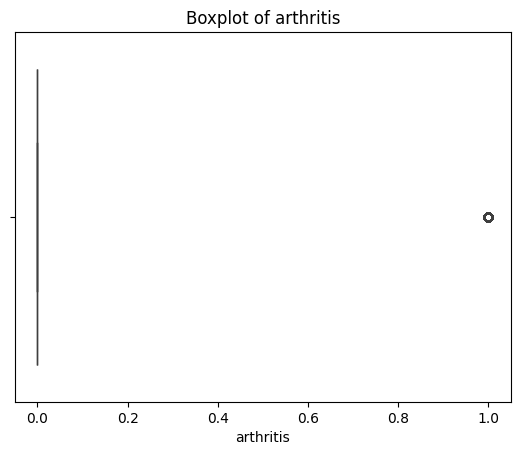

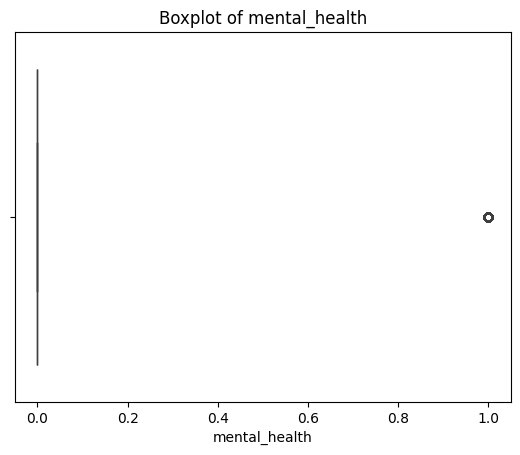

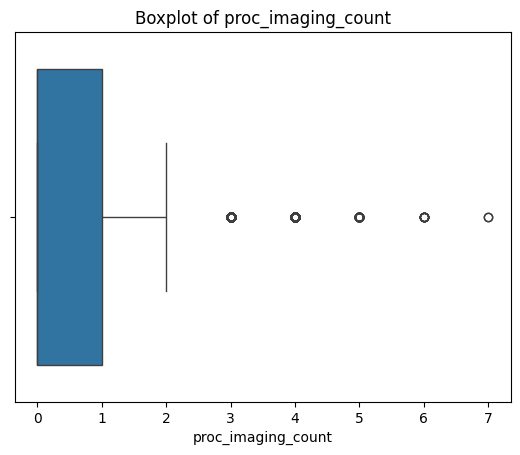

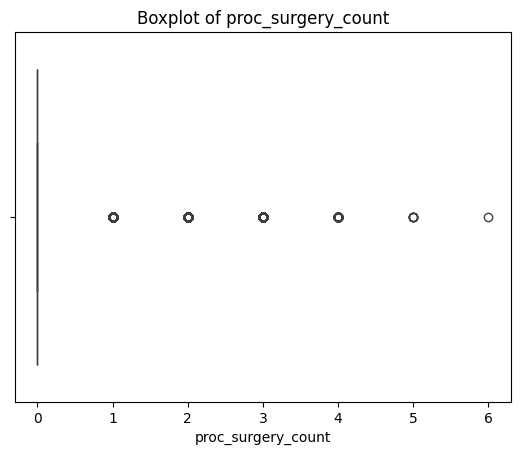

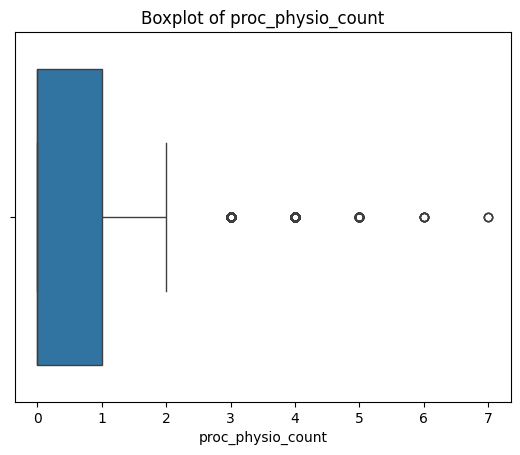

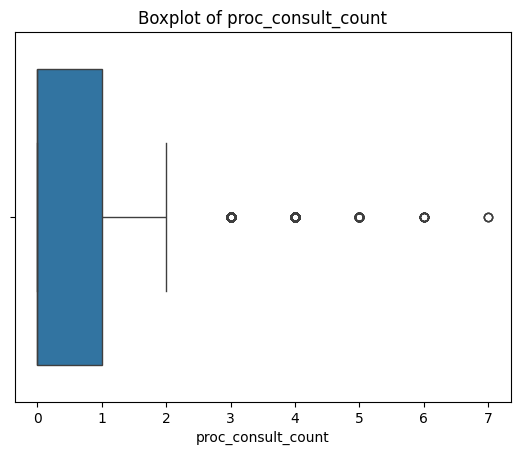

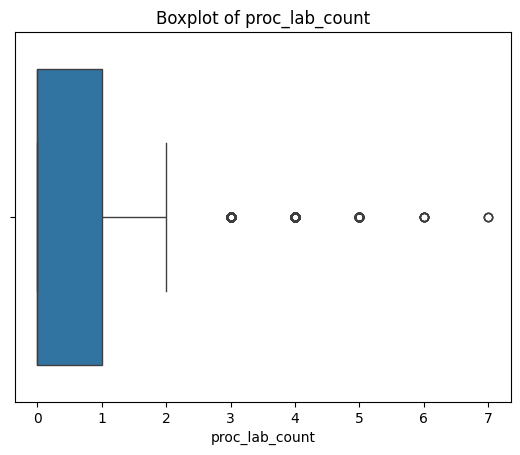

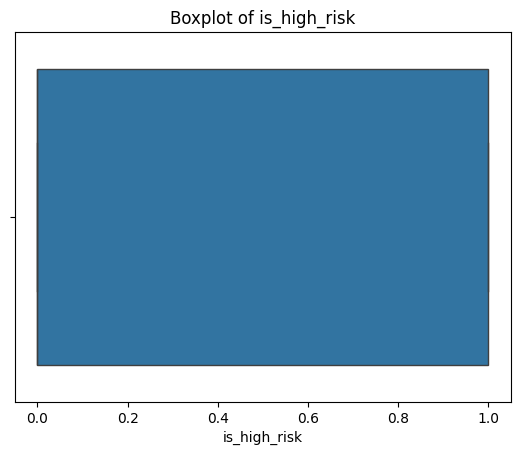

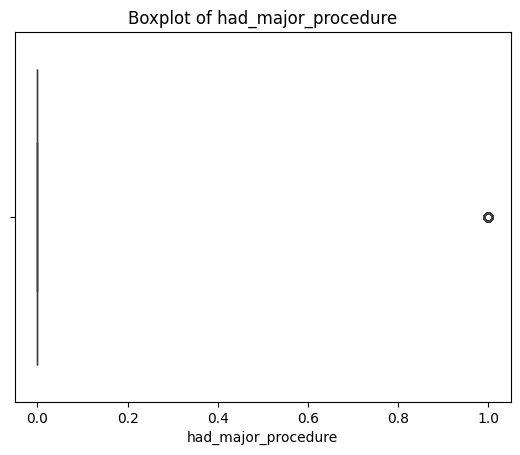

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
for col in df.select_dtypes(include='number').columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [21]:
def count_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)].shape[0]

outlier_counts = {col: count_outliers(col) for col in df.select_dtypes(include='number').columns}
sorted_outliers = sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)
outliers = sorted_outliers[:]
outliers

[('hypertension', 20345),
 ('had_major_procedure', 16970),
 ('mental_health', 13014),
 ('proc_surgery_count', 12519),
 ('arthritis', 10831),
 ('hospitalizations_last_3yrs', 8969),
 ('days_hospitalized_last_3yrs', 8969),
 ('diabetes', 8593),
 ('hba1c', 7465),
 ('total_claims_paid', 6963),
 ('annual_premium', 6927),
 ('monthly_premium', 6925),
 ('annual_medical_cost', 6772),
 ('avg_claim_amount', 6581),
 ('dependents', 6306),
 ('income', 6236),
 ('asthma', 5887),
 ('claims_count', 5154),
 ('cardiovascular_disease', 5117),
 ('deductible', 5013),
 ('policy_changes_last_2yrs', 4953),
 ('household_size', 4052),
 ('copd', 3595),
 ('chronic_count', 2778),
 ('cancer_history', 2151),
 ('proc_consult_count', 2131),
 ('proc_lab_count', 2090),
 ('visits_last_year', 2083),
 ('proc_imaging_count', 2070),
 ('proc_physio_count', 2036),
 ('liver_disease', 1477),
 ('kidney_disease', 1462),
 ('age', 864),
 ('diastolic_bp', 682),
 ('bmi', 676),
 ('ldl', 668),
 ('systolic_bp', 613),
 ('medication_count', 49

# 2 - Exploratory Data Analysis (EDA)

### 2.1 Distribution Plots

**📊 Histograms of Numerical Features**

We plotted histograms for all numeric columns to understand their distribution shapes, detect skewness, and identify potential outliers.


**🧁 Pie Charts of Categorical Features**

We visualized the distribution of all categorical columns using pie charts. This helps assess balance and frequency across categories such as:
- `sex`, `region`, `education`, `employment_status`, `plan_type`, `network_tier`, etc.


These visualizations guide preprocessing decisions like encoding, sampling, and transformation strategies.

**Histograms of numerical features**

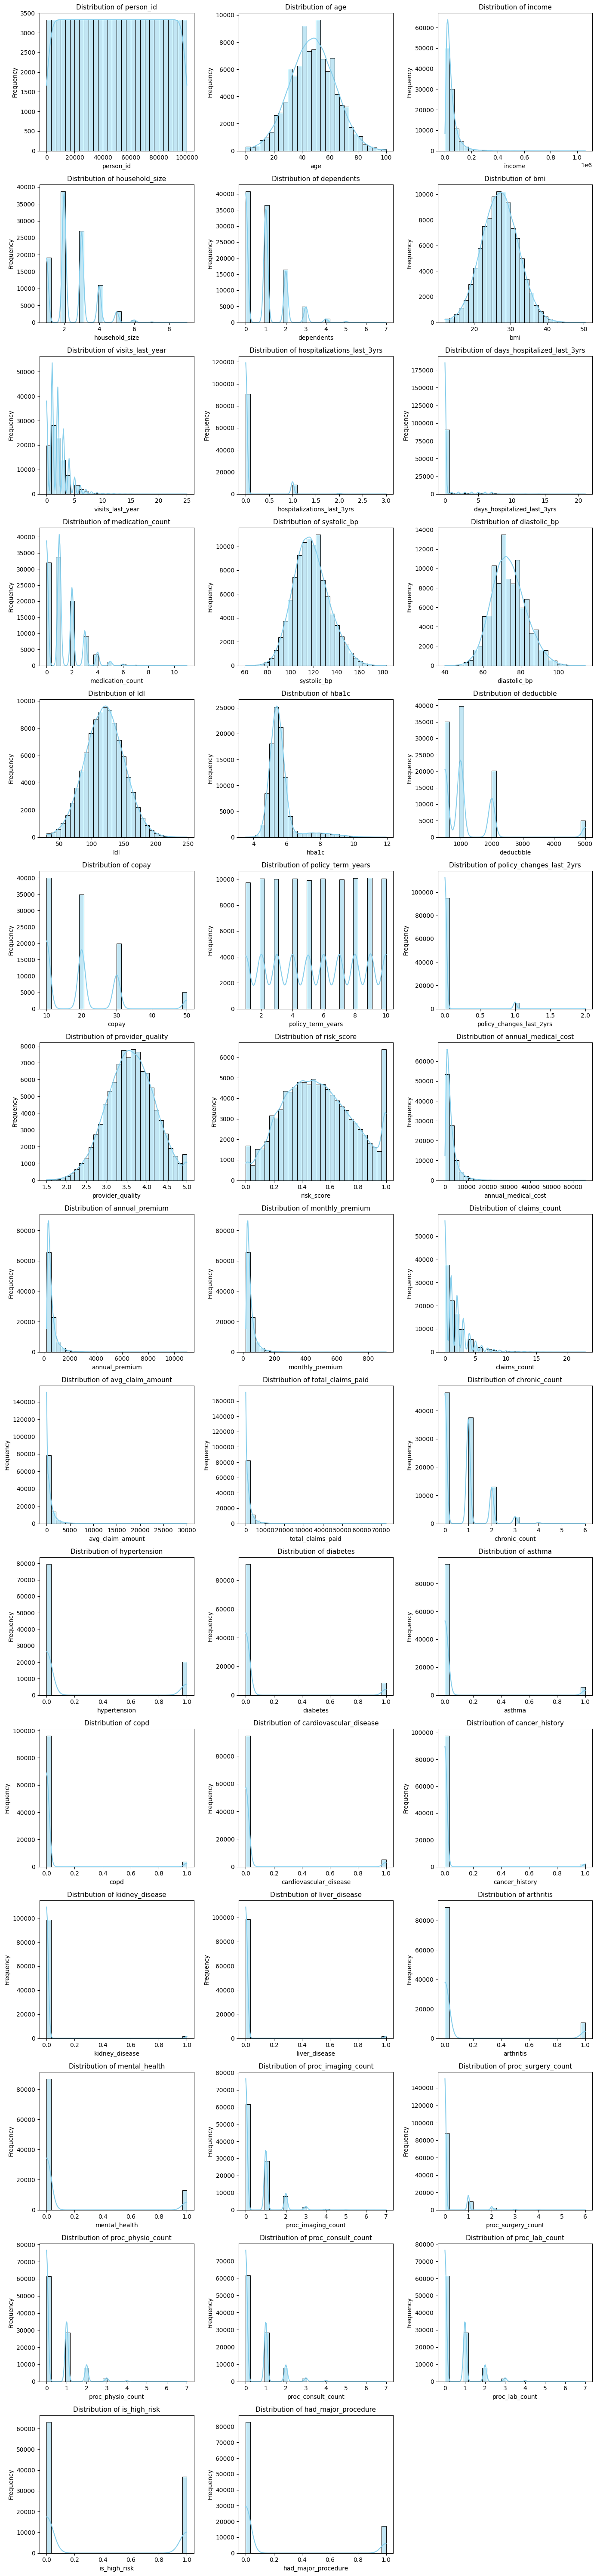

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = len(df.select_dtypes(include='number').columns)
rows = -(-num_cols // 3)
fig, axes = plt.subplots(rows, 3, figsize=(14, 4 * rows))
axes = axes.flatten() 

for i, col in enumerate(df.select_dtypes(include='number')):
    sns.histplot(df[col], kde=True, bins=30, color='skyblue', ax=axes[i])
    axes[i].set_title(f"Distribution of {col}", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Plots of categorical features**

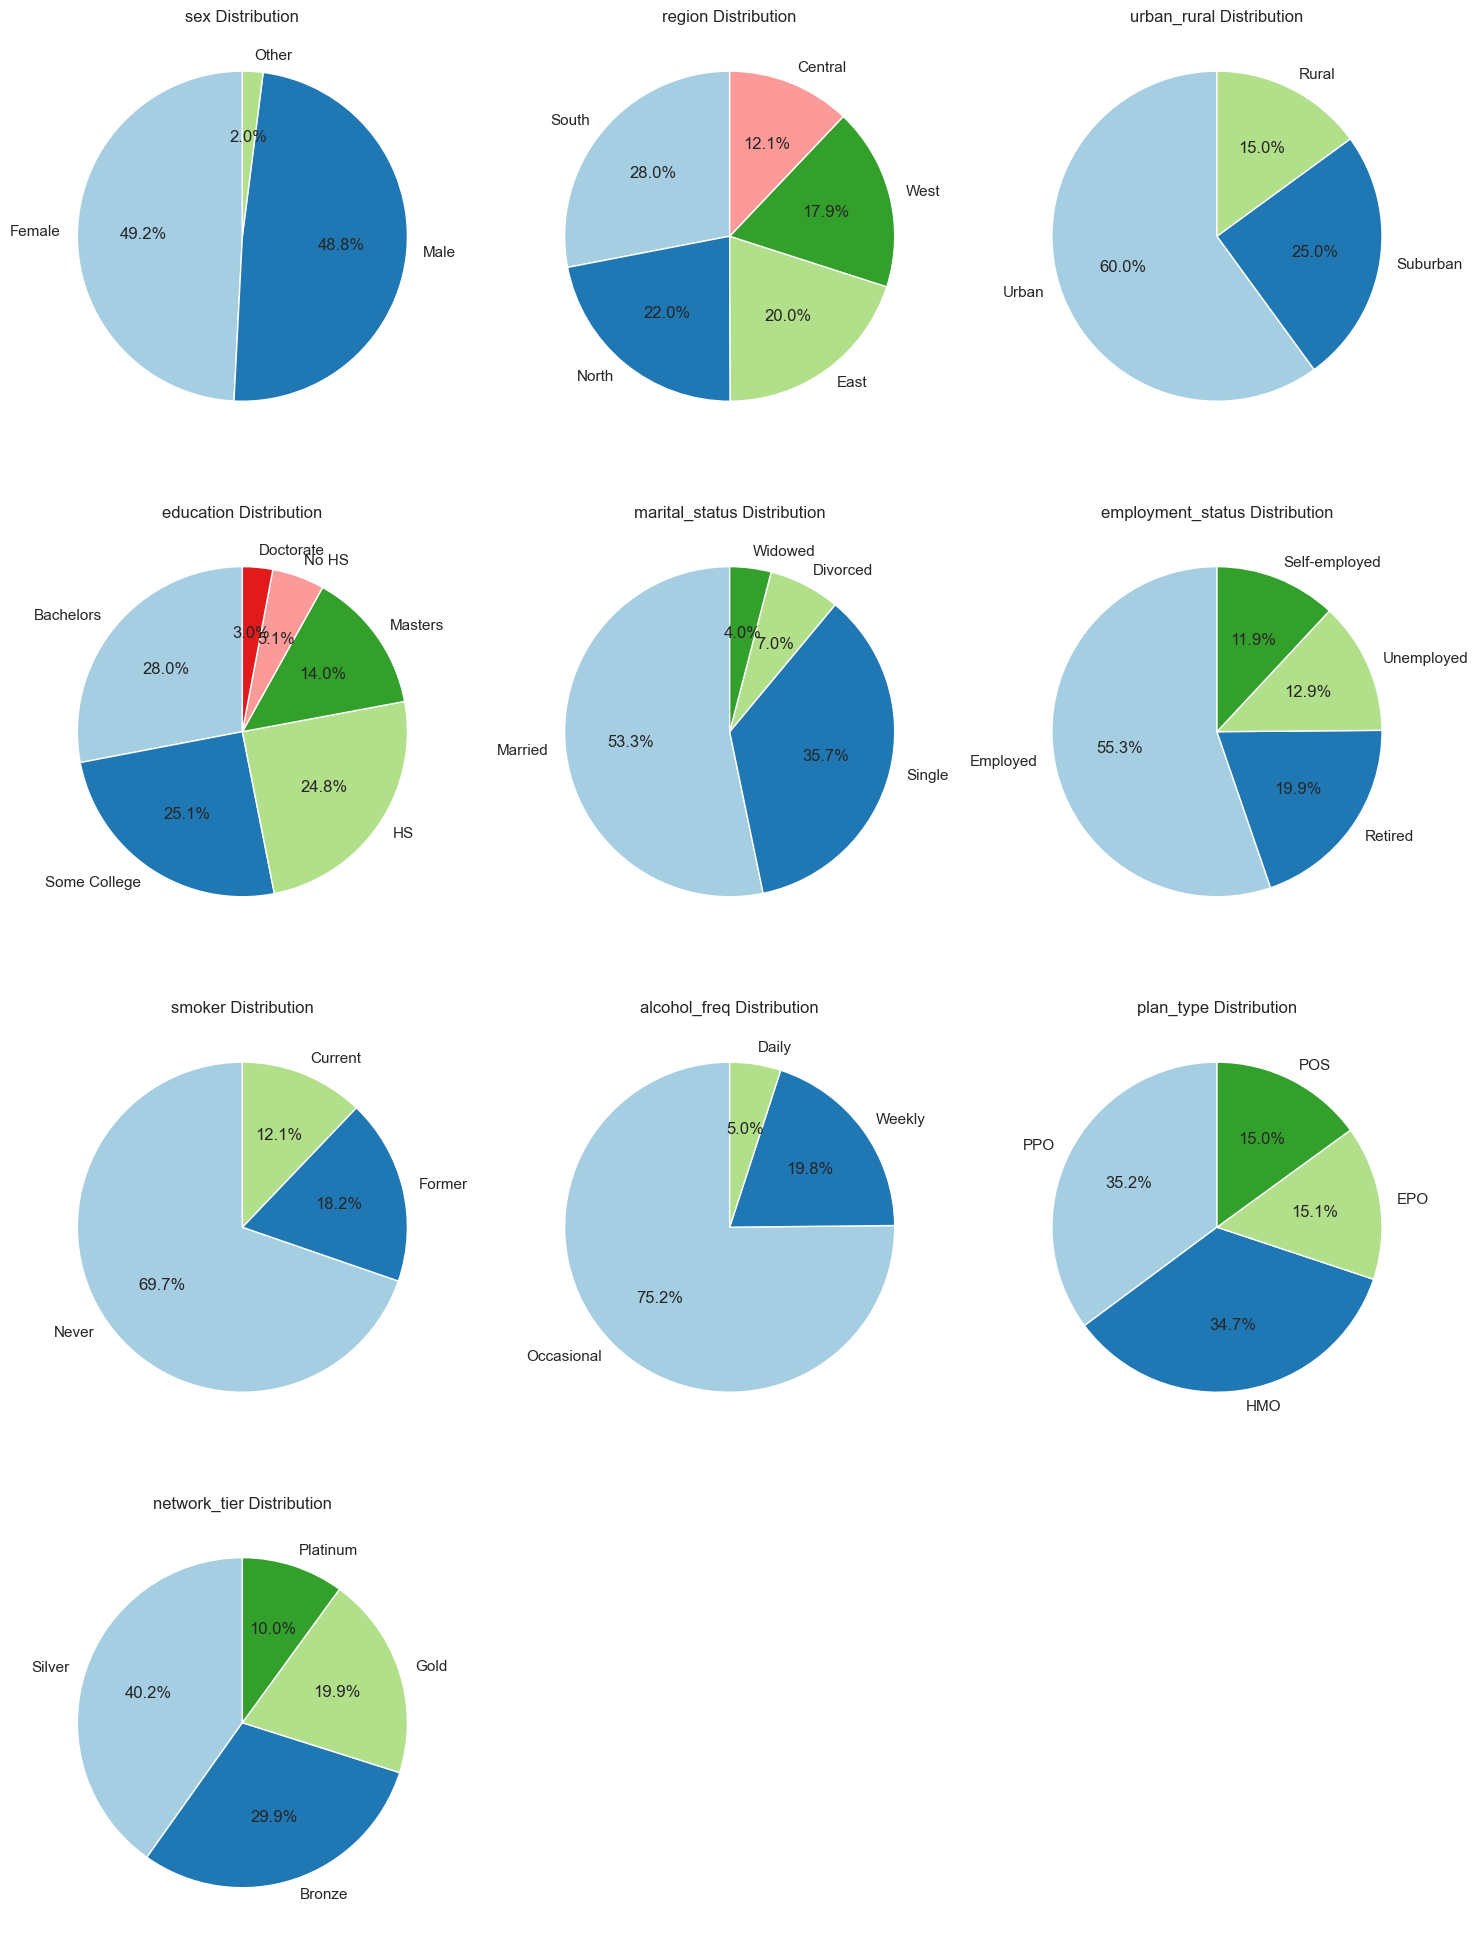

In [23]:
palette = sns.color_palette("Paired")
sns.set(style="whitegrid", palette=palette)
cat_cols = df.select_dtypes(include='object').columns
n = len(cat_cols)
rows = -(-n // 3)  
fig, axes = plt.subplots(rows, 3, figsize=(15, 5 * rows))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=palette, startangle=90,
           wedgeprops={'edgecolor': 'white'})
    ax.set_title(f'{col} Distribution')
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

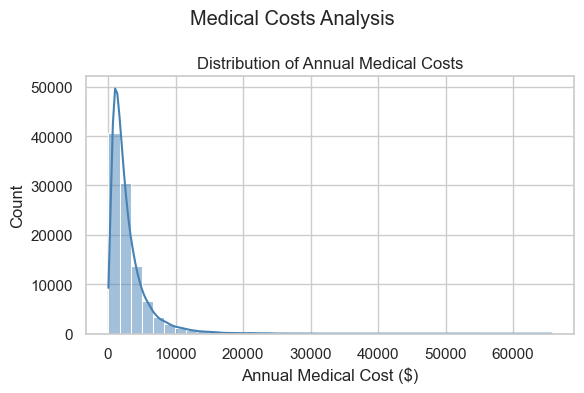

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
fig.suptitle('Medical Costs Analysis')
sns.histplot(df['annual_medical_cost'], bins=40, kde=True, ax=ax, color='steelblue')
ax.set_title('Distribution of Annual Medical Costs')
ax.set_xlabel('Annual Medical Cost ($)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show();

**Medical Costs Analysis**

Medical costs show a right-skewed distribution, with most expenses under $20,000.

#### Visualize Correlation


**To understand relationships between numeric features, we computed and visualized the correlation matrix.**

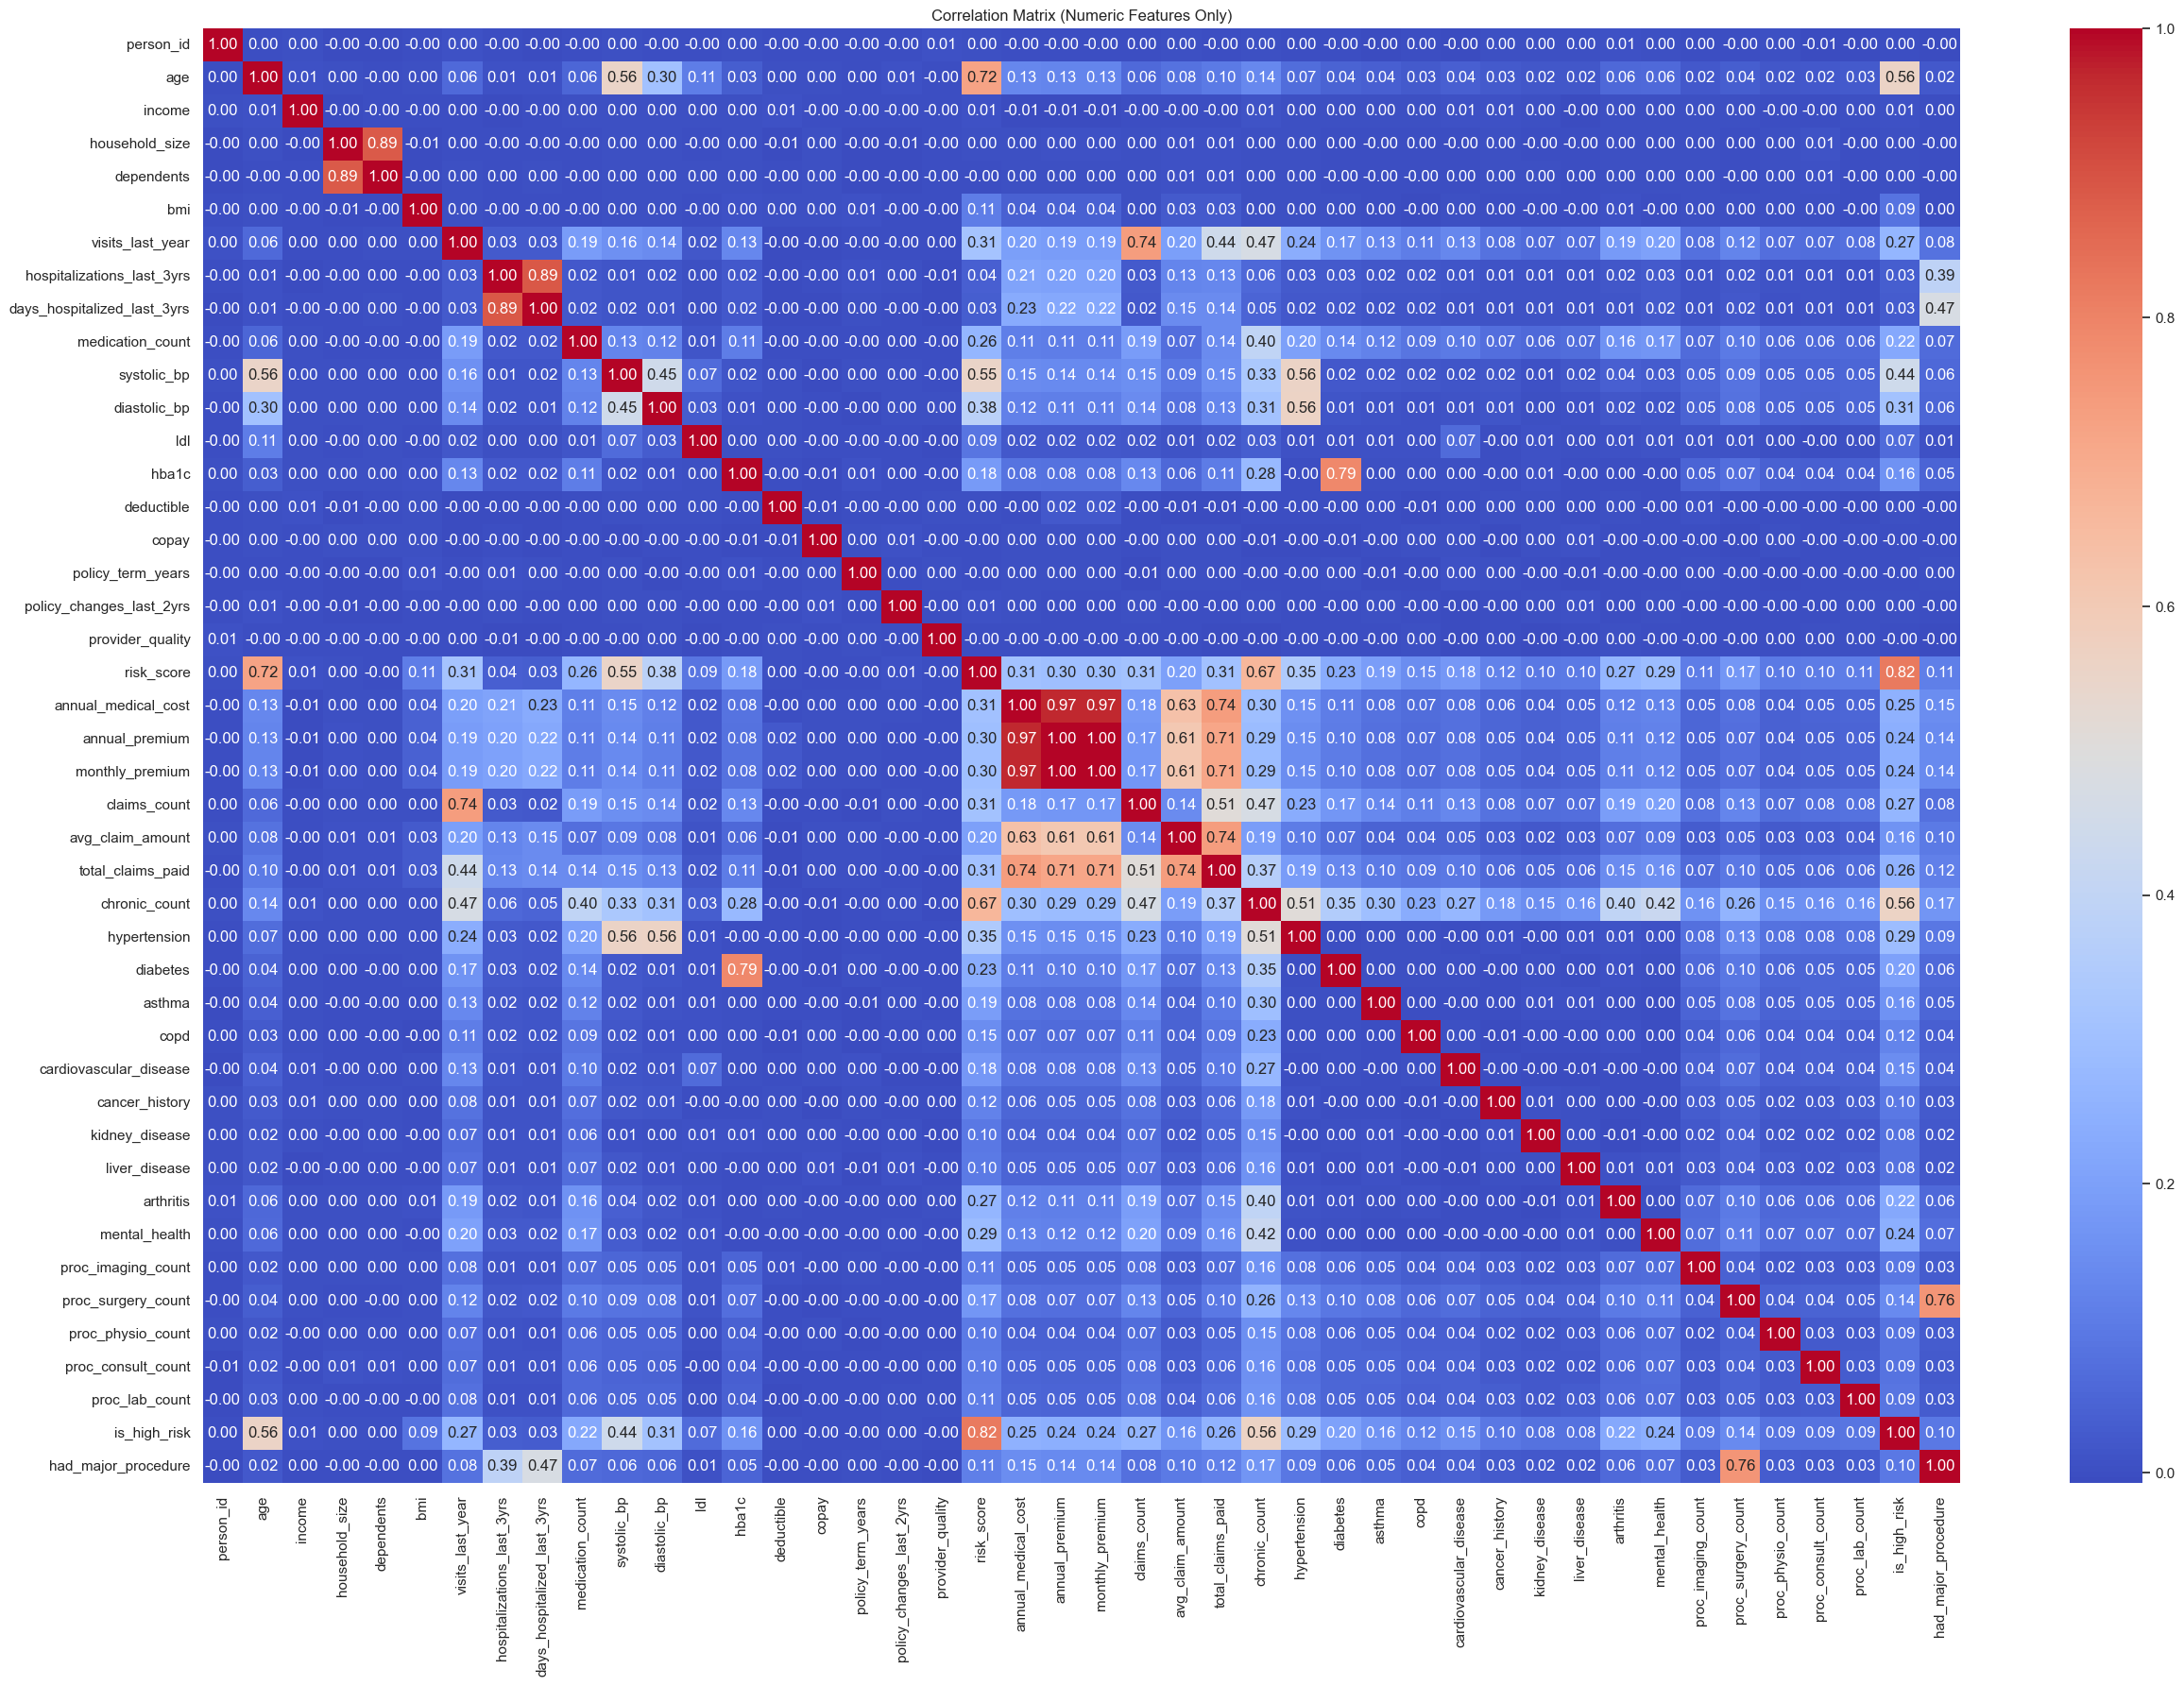

In [25]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(30,20))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()

**We plotted a heatmap of all numeric columns using Pearson correlation coefficients.**

- Strong positive correlations are shown in red, negative in blue.
- This helps identify multicollinearity and feature redundancy.


In [26]:
import numpy as np
round(np.abs(df.corr(numeric_only=True)['annual_medical_cost']).sort_values(ascending = False),2)

annual_medical_cost            1.00
monthly_premium                0.97
annual_premium                 0.97
total_claims_paid              0.74
avg_claim_amount               0.63
risk_score                     0.31
chronic_count                  0.30
is_high_risk                   0.25
days_hospitalized_last_3yrs    0.23
hospitalizations_last_3yrs     0.21
visits_last_year               0.20
claims_count                   0.18
hypertension                   0.15
had_major_procedure            0.15
systolic_bp                    0.15
age                            0.13
mental_health                  0.13
diastolic_bp                   0.12
arthritis                      0.12
medication_count               0.11
diabetes                       0.11
hba1c                          0.08
asthma                         0.08
cardiovascular_disease         0.08
proc_surgery_count             0.08
copd                           0.07
cancer_history                 0.06
proc_imaging_count          

**🎯 Correlation with Target: `annual_medical_cost`**

We also ranked features by their absolute correlation with `annual_medical_cost`.

**Top correlated features:**
- `monthly_premium`: 0.97  
- `annual_premium`: 0.97  
- `total_claims_paid`: 0.74  
- `avg_claim_amount`: 0.63  
- `risk_score`: 0.31  
- `chronic_count`: 0.30  
- `is_high_risk`: 0.25  

**Low or zero correlation:**
- `income`, `household_size`, `provider_quality`, `copay`, `deductible`, `policy_term_years`, `person_id`

These insights guide feature selection, transformation, and regularization strategies for modeling.


#### **Visualize Relationships (pairwise)**

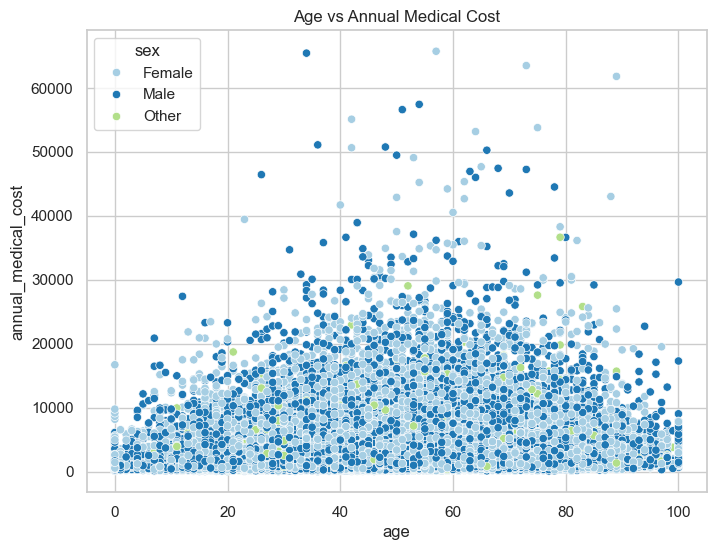

In [27]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="age", y="annual_medical_cost", hue="sex")
plt.title("Age vs Annual Medical Cost")
plt.show()

**Observations & Insights There is a high concentration of data points between ages 20 and 60, indicating that most individuals fall within this age range The majority of annual medical costs are below 20,000, suggesting relatively moderate spending for most people**

Several outliers show significantly higher medical costs, especially among middle-aged individuals

## 3- Feature Engineering

### 3.2 Scaling Numerical Features

**To prepare the dataset for machine learning models that are sensitive to feature magnitude, we applied two types of scaling based on feature distribution back to 2-1**

#####  StandardScaler for Normally Distributed Features
- Applied to features with approximately normal distributions.
- Transforms values to have **mean = 0** and **standard deviation = 1**.
- This ensures that features contribute equally to distance-based models (e.g., SVM, KNN, Logistic Regression).

##### MinMaxScaler for Skewed Features
- Applied to features with skewed or bounded distributions.
- Scales values to a **range between 0 and 1**.
- Preserves the shape of the original distribution while normalizing magnitude.



In [28]:
non_outliers_colmns = ['copay' , 'policy_term_years' , 'risk_score' , 'is_high_risk']
binary_cols = [
    'is_high_risk', 'hypertension', 'diabetes', 'asthma', 'copd',
    'cardiovascular_disease', 'cancer_history', 'kidney_disease',
    'liver_disease', 'arthritis', 'mental_health', 'had_major_procedure'
]
id_col = ['person_id']
target_col = ['annual_medical_cost']  

numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
numeric_features = numeric_features.drop(binary_cols + id_col + target_col + non_outliers_colmns)
numeric_features

Index(['age', 'income', 'household_size', 'dependents', 'bmi',
       'visits_last_year', 'hospitalizations_last_3yrs',
       'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp',
       'diastolic_bp', 'ldl', 'hba1c', 'deductible',
       'policy_changes_last_2yrs', 'provider_quality', 'annual_premium',
       'monthly_premium', 'claims_count', 'avg_claim_amount',
       'total_claims_paid', 'chronic_count', 'proc_imaging_count',
       'proc_surgery_count', 'proc_physio_count', 'proc_consult_count',
       'proc_lab_count'],
      dtype='object')

This output shows the list of continuous numerical columns that will be used for scaling after removing binary, ID, target, and non-outlier columns.


back to step 2.1 the distribution of the data and identify patterns, skewness, or normal , which helps decide which columns are suitable for scaling (StandardScaler or MinMaxScaler).

In [29]:
df[numeric_features].skew().sort_values(ascending=False)

total_claims_paid              4.938078
avg_claim_amount               4.642195
policy_changes_last_2yrs       4.400438
annual_premium                 4.364620
monthly_premium                4.364620
days_hospitalized_last_3yrs    4.257994
proc_surgery_count             3.472609
income                         3.390437
hospitalizations_last_3yrs     3.225356
hba1c                          2.637342
deductible                     2.497308
claims_count                   2.086701
proc_consult_count             1.655806
proc_lab_count                 1.629823
proc_imaging_count             1.627069
proc_physio_count              1.606152
visits_last_year               1.598202
medication_count               1.143470
dependents                     1.062228
chronic_count                  0.977679
household_size                 0.725711
systolic_bp                    0.262804
diastolic_bp                   0.250856
ldl                            0.019670
bmi                            0.016151


Interpretation of skewness values: Skew > 1 : Highly right-skewed 0.5 <= Skew <= 0.5 : Approximately symmetric (low skew) or normally distributed Skew < -1 : Highly left-skewed We do this to identify which columns may need transformation before scaling (StandardScaler or MinMaxScaler).

In [30]:
minmax_cols = [
    'total_claims_paid', 'avg_claim_amount', 'policy_changes_last_2yrs',
    'annual_premium', 'monthly_premium', 'days_hospitalized_last_3yrs',
    'proc_surgery_count', 'income', 'hospitalizations_last_3yrs', 'hba1c',
    'deductible', 'claims_count', 'proc_consult_count', 'proc_lab_count',
    'proc_imaging_count', 'proc_physio_count', 'visits_last_year',
    'medication_count', 'dependents', 'chronic_count', 'household_size'
]
standard_cols = [
    'systolic_bp', 'diastolic_bp', 'ldl', 'bmi',
    'age', 'provider_quality'
]

In [31]:
from sklearn.preprocessing import StandardScaler

scaler_standard = StandardScaler()
df_standard_scaled = df.copy()
df_standard_scaled[standard_cols] = scaler_standard.fit_transform(df[standard_cols])

df_standard_scaled.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,0.280105,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,1.968800,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,1.280813,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,-2.034034,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,0.342649,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


This output shows the first few rows of the DataFrame after applying StandardScaler to the selected normally distributed numerical features. The values in these columns are now standardized with a mean of 0 and a standard deviation of 1, making them ready for machine learning models that are sensitive to feature scaling.

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
df_minmax_scaled = df.copy()
df_minmax_scaled[minmax_cols] = scaler_minmax.fit_transform(df[minmax_cols])

df_minmax_scaled.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,0.020364,Doctorate,Married,Retired,0.250,...,0,1,0,0.142857,0.0,0.285714,0.000000,0.142857,0,0
1,80185,79,Female,North,Urban,0.011030,No HS,Married,Employed,0.250,...,0,1,1,0.000000,0.0,0.142857,0.000000,0.142857,1,0
2,19865,68,Male,North,Rural,0.037334,HS,Married,Retired,0.500,...,0,0,1,0.142857,0.0,0.285714,0.142857,0.000000,1,0
3,76700,15,Male,North,Suburban,0.013670,Some College,Married,Self-employed,0.500,...,0,0,0,0.142857,0.0,0.000000,0.142857,0.000000,0,0
4,92992,53,Male,Central,Suburban,0.083435,Doctorate,Married,Self-employed,0.125,...,0,1,0,0.285714,0.0,0.142857,0.142857,0.000000,1,0


This output shows the first few rows of the DataFrame after applying MinMaxScaler to the selected skewed numerical features. The values in these columns are now scaled to a range between 0 and 1, ensuring that all features contribute proportionally in machine learning models.

### 3.2 Encode Categorical Variables

In [33]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

sex: ['Female' 'Male' 'Other']
region: ['North' 'Central' 'West' 'South' 'East']
urban_rural: ['Suburban' 'Urban' 'Rural']
education: ['Doctorate' 'No HS' 'HS' 'Some College' 'Masters' 'Bachelors']
marital_status: ['Married' 'Single' 'Divorced' 'Widowed']
employment_status: ['Retired' 'Employed' 'Self-employed' 'Unemployed']
smoker: ['Never' 'Current' 'Former']
alcohol_freq: ['Occasional' 'Weekly' 'Daily']
plan_type: ['PPO' 'POS' 'HMO' 'EPO']
network_tier: ['Bronze' 'Gold' 'Platinum' 'Silver']


#### **OneHotEncoder**  
After exploring the object-type columns, we found that several categorical features (e.g., `region`, `education`, `employment_status`) do not have a meaningful order. Since the categories are nominal — where order doesn’t matter — we use `OneHotEncoder`.

**Steps:**  
- Identify categorical columns  
- Apply `OneHotEncoder` to convert each category into a separate binary column  
- Drop the original categorical columns and replace it with the encoded version

In [34]:
from sklearn.preprocessing import OneHotEncoder

def onehotencoder(data):
    encoder_columns = ['sex', 'region', 'urban_rural', 'education', 'marital_status',
                       'employment_status', 'smoker', 'alcohol_freq', 'plan_type']
    ohe= OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    return pd.concat([data.drop(columns=encoder_columns),
                      pd.DataFrame(ohe.fit_transform(data[encoder_columns]),
                                   columns=ohe.get_feature_names_out(encoder_columns),
                                   index=data.index)], axis=1)

In [35]:
onehotencoder(df)

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,smoker_Current,smoker_Former,smoker_Never,alcohol_freq_Daily,alcohol_freq_Occasional,alcohol_freq_Weekly,plan_type_EPO,plan_type_HMO,plan_type_POS,plan_type_PPO
0,75722,52,22700.0,3,1,27.4,2,0,0,4,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,80185,79,12800.0,3,1,26.6,2,0,0,3,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,19865,68,40700.0,5,3,31.5,1,0,0,4,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,76700,15,15600.0,5,3,31.6,0,0,0,1,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,92992,53,89600.0,2,0,30.5,3,0,0,2,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,50,127200.0,2,0,28.2,0,0,0,1,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
99996,54887,42,21600.0,2,0,27.6,0,0,0,1,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
99997,76821,41,81900.0,1,0,29.8,7,0,0,1,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
99998,861,51,43400.0,3,2,21.9,4,0,0,2,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


#### **OrdinalEncoder**  
The `network_tier` column represents ordered categories: `'Bronze' < 'Silver' < 'Gold' < 'Platinum'`. Since these tiers have a meaningful rank, we use `OrdinalEncoder` to preserve this order numerically.

**Steps:**  
- Define a custom order for the `network_tier` column  
- Apply `OrdinalEncoder` to convert tier names into ordered numeric values  
- Drop the original `network_tier` column and replace it with the encoded version


In [36]:
from sklearn.preprocessing import OrdinalEncoder

def ordinalencoder(data):
    tier_order = [['Bronze', 'Silver', 'Gold', 'Platinum']]
    ode = OrdinalEncoder(categories=tier_order)
    return pd.concat([
        data.drop(columns=['network_tier']),
        pd.DataFrame(ode.fit_transform(data[['network_tier']]), 
                     columns=ode.get_feature_names_out(['network_tier']), 
                     index=data.index)], axis=1)

In [37]:
ordinalencoder(df)

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,network_tier
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,1,0,1,0,2,0,1,0,0,0.0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,1,1,0,0,1,0,1,1,0,2.0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,1,1,0,2,1,0,1,0,3.0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,1,0,0,1,0,0,0,1.0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,1,0,2,0,1,1,0,1,0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,50,Male,West,Urban,127200.0,No HS,Married,Employed,2,...,0,0,0,0,1,0,0,0,0,0.0
99996,54887,42,Male,East,Suburban,21600.0,HS,Married,Employed,2,...,0,0,0,0,0,0,0,0,0,1.0
99997,76821,41,Male,West,Rural,81900.0,HS,Divorced,Unemployed,1,...,0,0,1,0,1,0,0,0,0,2.0
99998,861,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,...,0,1,0,0,2,2,1,0,0,0.0


# 3- Modeling

In [38]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

def simpleimputer(data):
    imputer= SimpleImputer(strategy='most_frequent')
    data['alcohol_freq'] = imputer.fit_transform(data[['alcohol_freq']])[:,0]
    return data

def normalize_column_names(data):
    data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')
    return data


def standardscaler(data):
    standard_cols = ['systolic_bp', 'diastolic_bp', 'ldl', 'bmi',
                     'age', 'provider_quality']
    scaler_standard = StandardScaler()
    df_standard_scaled = data.copy()
    df_standard_scaled[standard_cols] = scaler_standard.fit_transform(data[standard_cols])
    return df_standard_scaled

def minmaxscaler(data):
    minmax_cols = ['total_claims_paid', 'avg_claim_amount', 'policy_changes_last_2yrs',
                'annual_premium','days_hospitalized_last_3yrs',
                'proc_surgery_count', 'income', 'hospitalizations_last_3yrs', 'hba1c',
                'deductible', 'claims_count', 'proc_consult_count', 'proc_lab_count',
                'proc_imaging_count', 'proc_physio_count', 'visits_last_year',
                'medication_count', 'dependents', 'chronic_count', 'household_size']
    scaler_minmax = MinMaxScaler()
    df_minmax_scaled = data.copy()
    df_minmax_scaled[minmax_cols] = scaler_minmax.fit_transform(data[minmax_cols])
    return df_minmax_scaled


def onehotencoder(data):
    encoder_columns = ['sex', 'region', 'urban_rural', 'education', 'marital_status',
                       'employment_status', 'smoker', 'alcohol_freq', 'plan_type']
    ohe= OneHotEncoder(handle_unknown='ignore' , sparse_output=False)
    return pd.concat([data.drop(columns=encoder_columns),
                      pd.DataFrame(ohe.fit_transform(data[encoder_columns]),
                                   columns=ohe.get_feature_names_out(encoder_columns),
                                   index=data.index)], axis=1)

def ordinalencoder(data):
    tier_order = [['Bronze', 'Silver', 'Gold', 'Platinum']]
    ode = OrdinalEncoder(categories=tier_order)
    return pd.concat([data.drop(columns=['network_tier']),
                      pd.DataFrame(ode.fit_transform(data[['network_tier']]), 
                      columns=ode.get_feature_names_out(['network_tier']), 
                      index=data.index)], axis=1)

In [39]:
X = df.drop(columns=['annual_medical_cost']).iloc[:25000]
y = df['annual_medical_cost'].iloc[:25000]

def preprocessing(data):
    
    # drop some coulmns
    data = data.drop(columns=['monthly_premium', 'person_id'])
    
    # handle missing 
    data = simpleimputer(data)
    
    # scalling 
    data = standardscaler(data)
    data = minmaxscaler(data)
    
    # encoding 
    # for oridnal column
    data = ordinalencoder(data)
    # for the rest of data
    data = onehotencoder(data)
    
    # normalizing 
    # after onehot encoder 
    data = normalize_column_names(data)

    return data

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


#### Linear Regression model

In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()

X_train_processed = preprocessing(X_train)
X_test_processed = preprocessing(X_test)

lr_model.fit(X_train_processed, y_train)

# Predict
y_pred = lr_model.predict(X_test_processed)


In [42]:
# Evaluate model
lr_mae = mean_absolute_error(y_test, y_pred)
lr_mse = mean_squared_error(y_test, y_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred)
lr_mean_actual = y_test.mean()
accuracy_percentage = (1 - (lr_mae / lr_mean_actual)) * 100

print("Linear Regression Performance Metrics")
print(f"• MAE (Mean Absolute Error): {lr_mae:,.2f}")
print(f"• MSE (Mean Squared Error): {lr_mse:,.2f}")
print(f"• RMSE (Root Mean Squared Error): {lr_rmse:,.2f}")
print(f"• R² Score: {lr_r2:.4f}")
print(f"• Accuracy: {accuracy_percentage:.2f}%")


Linear Regression Performance Metrics
• MAE (Mean Absolute Error): 656.47
• MSE (Mean Squared Error): 1,146,205.38
• RMSE (Root Mean Squared Error): 1,070.61
• R² Score: 0.8936
• Accuracy: 78.25%


##### The model achieved an *R²* of 0.89, indicationg that 89% of the variance in annual medical cost can be explained by the selected predictors

#### Decision Tree model

In [45]:
from sklearn.tree import DecisionTreeRegressor

# Train model
tree_model = DecisionTreeRegressor(random_state=42,max_depth=5, min_samples_split=40, min_samples_leaf=20, max_features=0.8)

tree_model.fit(X_train_processed,y_train)

# Predict
y_pred = tree_model.predict(X_test_processed)

In [47]:
# Evaluate model
tree_mae = mean_absolute_error(y_test, y_pred)
tree_mse = mean_squared_error(y_test, y_pred)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, y_pred)

mean_actual_tree = y_test.mean()
accuracy_percentage_tree = (1 - (tree_mae / mean_actual_tree)) * 100

print("Decision Tree Performance Metrics")
print(f"• MAE (Mean Absolute Error): {tree_mae:,.2f}")
print(f"• MSE (Mean Squared Error): {tree_mse:,.2f}")
print(f"• RMSE (Root Mean Squared Error): {tree_rmse:,.2f}")
print(f"• R² Score: {tree_r2:.4f}")
print(f"• Accuracy: {accuracy_percentage_tree:.2f}%")

# Cross-validation
cv_results = cross_validate(tree_model, X_train_processed, y_train, scoring="r2", cv=5, return_train_score=True)

print(f"\nCross-Validation R² Score: {cv_results}")
print(f"Train R² Mean: {cv_results['train_score'].mean():.3f}")
print(f"Test R² Mean:  {cv_results['test_score'].mean():.3f}")

Decision Tree Performance Metrics
• MAE (Mean Absolute Error): 564.74
• MSE (Mean Squared Error): 1,095,048.76
• RMSE (Root Mean Squared Error): 1,046.45
• R² Score: 0.8984
• Accuracy: 81.29%

Cross-Validation R² Score: {'fit_time': array([0.17128825, 0.11573935, 0.111202  , 0.09571218, 0.09824371]), 'score_time': array([0.00864983, 0.00483394, 0.00400615, 0.00574613, 0.00400901]), 'test_score': array([0.9405035 , 0.95371992, 0.90318632, 0.93584303, 0.91993926]), 'train_score': array([0.94181806, 0.94105915, 0.95598786, 0.94487583, 0.93340134])}
Train R² Mean: 0.943
Test R² Mean:  0.931


##### Decision Tree Model Performance Summary:
R² Score: 0.8984 - The model explains 89.84% of variance in medical costs

#### 4.4 residuals, learning curves

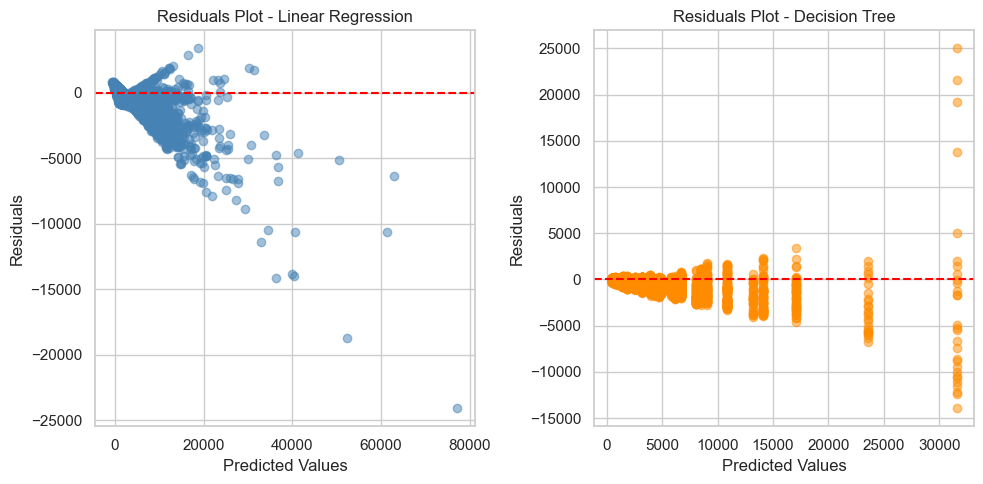

In [48]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

# ===== Linear Regression Residuals =====
y_pred_lr = lr_model.predict(X_test_processed)
residuals_lr = y_test - y_pred_lr

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(y_pred_lr, residuals_lr, alpha=0.5, color="steelblue")
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals Plot - Linear Regression")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# ===== Decision Tree Residuals =====
y_pred_tree = tree_model.predict(X_test_processed)
residuals_tree = y_test - y_pred_tree

plt.subplot(1,2,2)
plt.scatter(y_pred_tree, residuals_tree, alpha=0.5, color="darkorange")
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals Plot - Decision Tree")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

In [49]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    plt.figure(figsize=(5,4))
    plt.plot(train_sizes, train_mean, 'o-', label='Training Score', color='royalblue')
    plt.plot(train_sizes, val_mean, 'o-', label='Validation Score', color='darkorange')
    plt.title(f'Learning Curve: {title}', fontsize=14, fontweight='bold')
    plt.xlabel('Training Set Size')
    plt.ylabel('R² Score')
    plt.legend()
    plt.grid(True)
    plt.show()


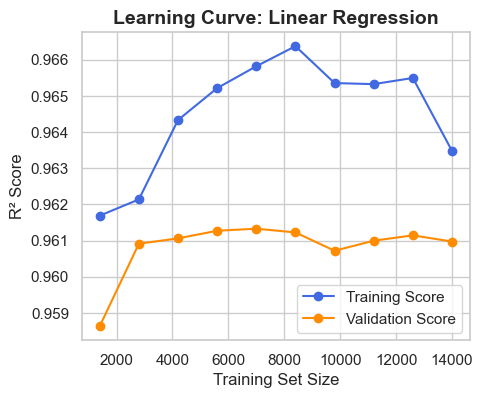

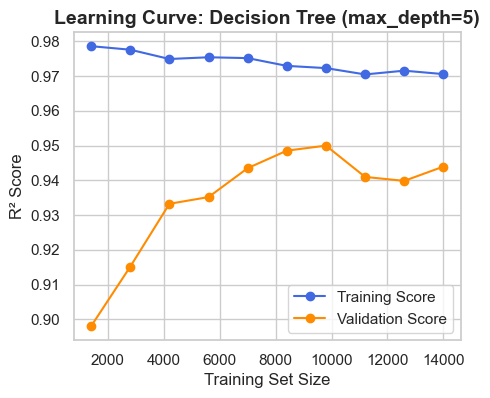

In [50]:
models = [
    (LinearRegression(), "Linear Regression"),
    (DecisionTreeRegressor(max_depth=5, random_state=42), "Decision Tree (max_depth=5)")
]

for model, name in models:
    plot_learning_curve(model, X_train_processed, y_train, name)


#### 5- Hyperparameter Tuning

#### 5.1.1 GridsearchCV for linear regression
Lasso is a regularized version of Linear Regression that uses L1 regularization to penalize large coefficients. This technique helps reduce overfitting by shrinking some feature coefficients to zero, effectively performing feature selection and improving the model’s generalization performance.

In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

#Lasso Regression
lasso = Lasso(max_iter=10000, random_state=42)
param_grid_lasso = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

lasso_grid = GridSearchCV(lasso, param_grid_lasso, cv=5, scoring='r2')
lasso_grid.fit(X_train_processed, y_train)

print("Best Params for Lasso:", lasso_grid.best_params_)
print("Best R² (CV):", lasso_grid.best_score_)

Best Params for Lasso: {'alpha': 1}
Best R² (CV): 0.9610899036898959


In [52]:
# Best score
lasso_grid.best_score_

# Best Params
lasso_grid.best_params_

# Best estimator
lasso_grid.best_estimator_

,alpha,1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,10000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


##### The Lasso Regression model achieved a cross-validated R² score of 0.961, indicating a strong fit between the predicted and actual values.

#### 5.1.2 GridsearchCV for Decision Tree

In [53]:
# Decision Tree
tree = DecisionTreeRegressor(random_state=42)
param_grid_tree = {
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}
tree_grid = GridSearchCV(tree, param_grid_tree, cv=5, scoring='r2', n_jobs=-1)
tree_grid.fit(X_train_processed, y_train)
print("Best Params for Decision Tree:", tree_grid.best_params_)

Best Params for Decision Tree: {'max_depth': 9, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [59]:
print("Best R² (CV):", tree_grid.best_score_)

# Best score
tree_grid.best_score_

# Best Params
tree_grid.best_params_

# Best estimator
tree_grid.best_estimator_

Best R² (CV): 0.9830454827333466


,criterion,'squared_error'
,splitter,'best'
,max_depth,9
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


##### The tuned Decision Tree model achieved a good performance with an R² (CV) of 0.98, indicating that it explains nearly all the variability in the target variable. However, such a high score suggests that the model might be overfitting the training data.

#### 5.2 Compares model performance

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)
    return [name, mae, mse, rmse, r2]

results = []

# Evaluate original models
results.append(evaluate_model("Linear Regression", lr_model, X_test_processed, y_test))
results.append(evaluate_model("Decision Tree", tree_model, X_test_processed, y_test))

# Evaluate tuned models
results.append(evaluate_model("Lasso (Tuned)", lasso_grid.best_estimator_, X_test_processed, y_test))
results.append(evaluate_model("Decision Tree (Tuned)", tree_grid.best_estimator_, X_test_processed, y_test))

# Create DataFrame
results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R²"])
display(results_df)

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,656.466912,1.146205e+06,1070.609819,0.893626
1,Decision Tree,564.738080,1.095049e+06,1046.445774,0.898373
2,Lasso (Tuned),637.931511,1.064570e+06,1031.779974,0.901202
3,Decision Tree (Tuned),515.166524,9.607698e+05,980.188632,0.910835


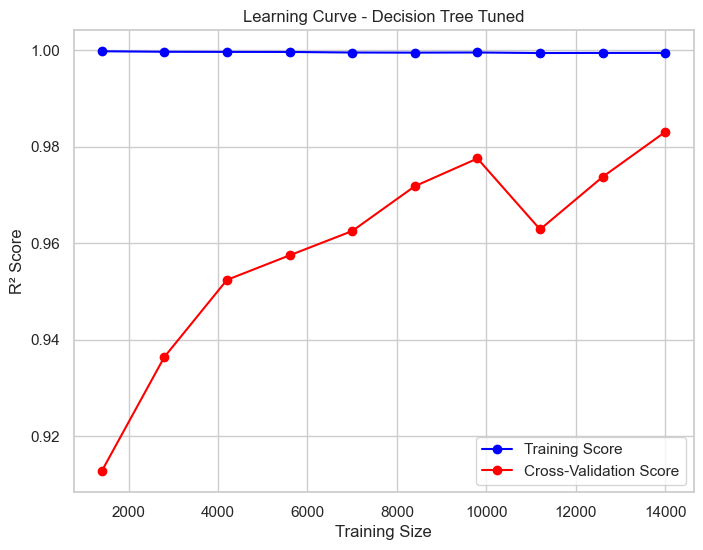

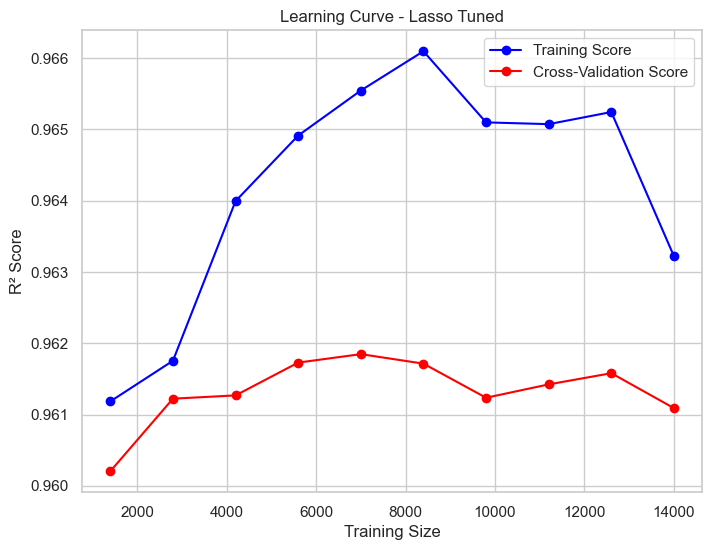

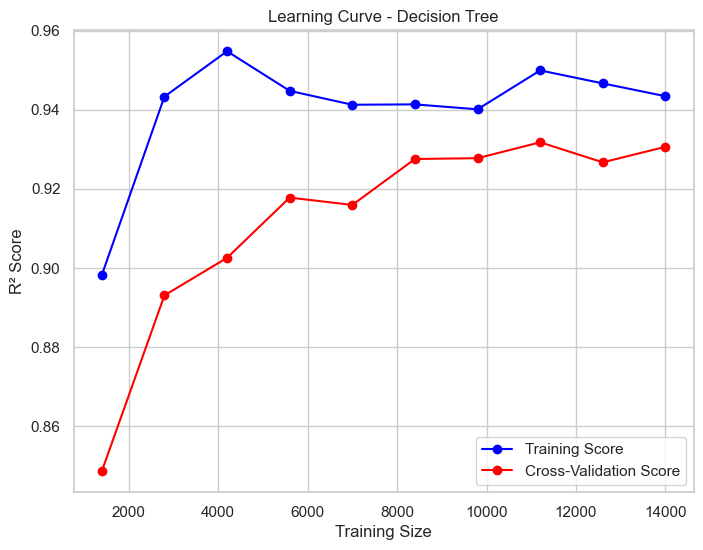

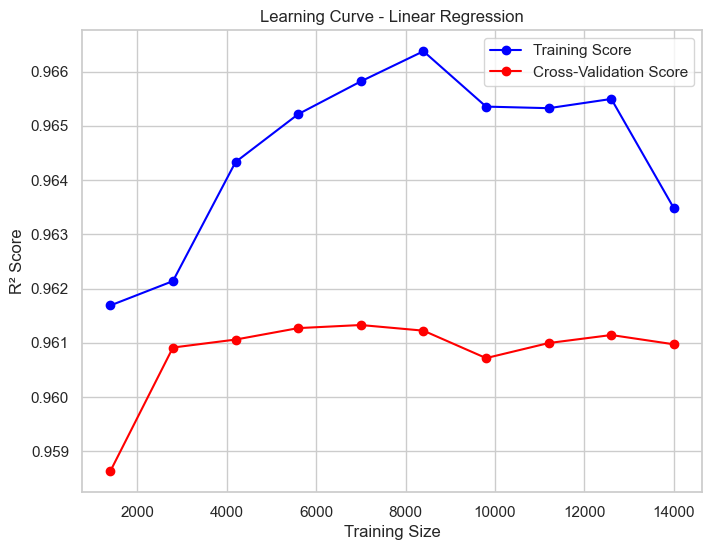

In [67]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

def plot_learning_curve_comparison(model, name, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    plt.plot(train_sizes, test_mean, 'o-', color='red', label='Cross-Validation Score')
    plt.title(f'Learning Curve - {name}')
    plt.xlabel('Training Size')
    plt.ylabel('R² Score')
    plt.legend()
    plt.grid(True)
    plt.show()

for name, model in models.items():
    plot_learning_curve_comparison(model, name, X_train_processed, y_train)
    